# Define Dictionaries and Parameters


In [85]:
JUPYTER_LAB = True # False for jupyter hub or notebook

if not JUPYTER_LAB: # jupyterhub
    %matplotlib notebook  
else:
    %matplotlib widget 

import matplotlib.pyplot as plt

from ipywidgets import Dropdown, Output, IntText, ToggleButton, Text
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path
import json
import os
import subprocess
import numpy as np
import time

# --- Define your dictionaries ---
xy = [949, 1169]  # Example, adjust as needed
xy = [1358, 1952]  # Example, adjust as needed

d13 = {
    'scantype': 'map',
    'roicenter': xy,
    'prefix': 'eiger4m_',
    'suffix': 'h5',
    'folder': '/data/visitor/blc16859/bm32/20260210/RAW_DATA/NiTi_Heraud/NiTi_Heraud_map/scan0013',
    'CCDLabel': 'EIGER_4MCdTe',
    #'listindices': list(range(41 * (2482 // 41))),
    'listindices': list(range(41 * (2910 // 41))),
    'mapdimensions': (41, 201),
    'nbimagesperline': 41,
    'fastaxis': 'yech',
    'slowaxis': 'xech'
}

d5 = {
    'scantype': 'map',
    'roicenter': xy,
    'prefix': 'eiger4m_',
    'suffix': 'h5',
    'folder': '/data/visitor/blc16859/bm32/20260210/RAW_DATA/NiTi_Heraud/NiTi_Heraud_NiTi2/scan0005',
    'CCDLabel': 'EIGER_4MCdTe',
    'listindices': list(range(21 * 41)),
    'mapdimensions': (21, 41),
    'nbimagesperline': 21,
    'fastaxis': 'yech',
    'slowaxis': 'xech'
}

# blc17163  /data/visitor/blc17163/bm32/20260609/RAW_DATA/BaTiO3/BaTiO3_Map
d1 = {
    'scantype': 'map',
    'roicenter': xy,
    'prefix': 'eiger4m_',
    'suffix': 'h5',
    'folder': '/data/visitor/blc17163/bm32/20260609/RAW_DATA/BaTiO3/BaTiO3_Map/scan0001/',
    'CCDLabel': 'EIGER_4MCdTe',
    'listindices': list(range(101 * 101)),
    'mapdimensions': (101, 101),
    'nbimagesperline': 101,
    'fastaxis': 'yech',
    'slowaxis': 'xech'
}

# --- Default parameters ---
boxsize_X, boxsize_Y = 13, 13
AUTOCONTRAST = False
ACQUISITON_ON = False
nbcompletelines = None #3  #  None

# --- Widgets for parameters ---
boxsize_X_widget = IntText(value=boxsize_X, description='boxsize_X:')
boxsize_Y_widget = IntText(value=boxsize_Y, description='boxsize_Y:')
AUTOCONTRAST_widget = ToggleButton(value=AUTOCONTRAST, description='AUTOCONTRAST', disabled=False)
ACQUISITON_ON_widget = ToggleButton(value=ACQUISITON_ON, description='ACQUISITON_ON', disabled=False)
nbcompletelines_widget = Text(value=str(nbcompletelines), description='nbcompletelines:', disabled=False)

# --- Display parameter widgets ---
display(boxsize_X_widget, boxsize_Y_widget, AUTOCONTRAST_widget, ACQUISITON_ON_widget, nbcompletelines_widget)

IntText(value=13, description='boxsize_X:')

IntText(value=13, description='boxsize_Y:')

ToggleButton(value=False, description='AUTOCONTRAST')

ToggleButton(value=False, description='ACQUISITON_ON')

Text(value='None', description='nbcompletelines:')

In [86]:
print('Selected boxsize',boxsize_X_widget.value,boxsize_Y_widget.value)

Selected boxsize 13 13


In [87]:
# --- Define available partitions and their configurations ---

partition_configs = {
    'magnifix': {'nbcpus': 96, 'partition': 'magnifix', 'constraint': 'NONE', 'comment': '#', 'nodes': 1},
    'magnifix2': {'nbcpus': 96 * 2, 'partition': 'magnifix', 'constraint': 'NONE', 'comment': '#', 'nodes': 1},
    'ub20': {'nbcpus': 96, 'partition': 'ub20', 'constraint': 'NONE', 'comment': '#', 'nodes': 1},
    'hpc7': {'nbcpus': 96, 'partition': 'nice', 'constraint': 'hpc7', 'comment': '', 'nodes': 1},
    'hpc8': {'nbcpus': 64, 'partition': 'nice', 'constraint': 'hpc8', 'comment': '', 'nodes': 1},
    'hpc6': {'nbcpus': 40, 'partition': 'nice', 'constraint': 'hpc6', 'comment': '', 'nodes': 1},
    'lbm32gpu1': {'nbcpus': 72, 'partition': None, 'constraint': 'NONE', 'comment': '#', 'nodes': 1},
    'hpc6-01': {'nbcpus': 64, 'partition': None, 'constraint': 'NONE', 'comment': '#', 'nodes': 1},
    'hpc6-02': {'nbcpus': 64, 'partition': None, 'constraint': 'NONE', 'comment': '#', 'nodes': 1},
    'hpc6-03': {'nbcpus': 64, 'partition': None, 'constraint': 'NONE', 'comment': '#', 'nodes': 1},
    'hpc6-04': {'nbcpus': 64, 'partition': None, 'constraint': 'NONE', 'comment': '#', 'nodes': 1}
}

# --- Create dropdown widget for partition selection ---
partition_dropdown = Dropdown(
    options=list(partition_configs.keys()),
    value='magnifix', #'hpc7',  # Default to 'ub20'
    description='Partition:',
    disabled=False,
)

# --- Create dropdown widget for dictionary selection ---
dict_dropdown = Dropdown(
    options=['d13', 'd5', 'd1'],
    value='d1',
    description='Dictionary:',
    disabled=False,
)

# --- Display widgets ---
display(partition_dropdown, dict_dropdown)



Dropdown(description='Partition:', options=('magnifix', 'magnifix2', 'ub20', 'hpc7', 'hpc8', 'hpc6', 'lbm32gpu…

Dropdown(description='Dictionary:', index=2, options=('d13', 'd5', 'd1'), value='d1')

In [ ]:
# --- Function to update partition settings ---
def update_partition_config(change):
    global ESRFmachine, nbcpus, partition, constraint, comment, nodes, forced_ncpus, ntasks, ncpuspertask, commenttask
    selected_partition = change['new']
    config = partition_configs[selected_partition]
    ESRFmachine = selected_partition
    nbcpus = config['nbcpus']
    partition = config['partition']
    constraint = config['constraint']
    comment = config['comment']
    nodes = config['nodes']
    forced_ncpus = config['nbcpus']

    if ESRFmachine in ('hpc7', 'ub20', 'magnifix', 'magnifix2'):
        ntasks = 1
        ncpuspertask = forced_ncpus
        commenttask =''
    else:
        ntasks = forced_ncpus
        ncpuspertask = 1
        commenttask ='#'

# --- Function to update selected dictionary ---
def update_selected_dict(change):
    global selected_dict
    selected_dict = globals()[change['new']]

# --- Attach the update functions to the dropdowns ---
partition_dropdown.observe(update_partition_config, names='value')
dict_dropdown.observe(update_selected_dict, names='value')

# --- Initialize with default values ---
update_partition_config({'new': partition_dropdown.value})
update_selected_dict({'new': dict_dropdown.value})

print('ESRFmachine',ESRFmachine)
print('selected_dict',selected_dict)

# generate config.json

In [72]:
# --- Generate config file ---
config = {
    "d": selected_dict,
    "boxsize_X": boxsize_X_widget.value,
    "boxsize_Y": boxsize_Y_widget.value,
    "AUTOCONTRAST": AUTOCONTRAST_widget.value,
    "ACQUISITON_ON": ACQUISITON_ON_widget.value,
    "nbcompletelines": (int(nbcompletelines_widget.value) if nbcompletelines_widget.value not in ("", "None") else None
)
}

# Convert tuples to lists for JSON serialization
for key, value in config["d"].items():
    if isinstance(value, tuple):
        config["d"][key] = list(value)

config_file_path = os.path.join(selected_dict['folder'], 'mosaic_config.json')
with open(config_file_path, 'w') as f:
    json.dump(config, f, indent=2)   #   indent = 4  or 2 ?!
 
print(f"Config file generated at: {config_file_path}")

# --- Generate SLURM script ---
script_folder = "/data/bm32/inhouse/LAUESCRIPTS/notebooks/LaueTools_script/"
script_python_file = "mosaic_compute.py"
script_path = str(Path(script_folder+'//'+script_python_file))


Config file generated at: /data/visitor/blc17163/bm32/20260609/RAW_DATA/BaTiO3/BaTiO3_Map/scan0001/mosaic_config.json


# create .sh file

In [73]:
partition= 'magnifix'
ncpuspertask = 120

In [74]:
shell_file = Path(script_folder)/'mosaicmagnifix.sh'

shell_script =f"""#!/bin/bash -l
#SBATCH -n 1                # Number of tasks
#SBATCH -c {ncpuspertask}               # CPUs per task
#SBATCH -p {partition}
#SBATCH --time=00:01:00    # Time limit
#SBATCH --mem-per-cpu=80M

module load mamba
conda activate /data/bm32/inhouse/SOFT/lauetoolsDEV

which python
echo 'launching python script for mosaic'
python {script_path} --config {config_file_path} --ncpus {ncpuspertask}"""

with open(shell_file, 'w') as f:
    f.write(shell_script)

print(f"SLURM script generated at: {shell_file}")

SLURM script generated at: /data/bm32/inhouse/LAUESCRIPTS/notebooks/LaueTools_script/mosaicmagnifix.sh


In [75]:
!cd {script_folder}

In [76]:
#!ls -alptr {script_folder}

In [77]:
!chmod 744 mosaicmagnifix.sh

In [78]:
#!chmod 744 {shell_file}  does not work

In [79]:
!sbatch mosaicmagnifix.sh

Submitted batch job 33318899


In [81]:
!squeue -u micha

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)


## OR [OPTION] command to run the python script to be launched directly on any slurm machine (rnice, cluster-access)

before that :

- module load mamba
- conda activate /data/bm32/inhouse/SOFT/lauetoolsDEV

In [53]:
print('module load mamba')
print('conda activate /data/bm32/inhouse/SOFT/lauetoolsDEV')

module load mamba
conda activate /data/bm32/inhouse/SOFT/lauetoolsDEV


In [41]:
print(f"python {script_path} --config {config_file_path} --ncpus {forced_ncpus}")

python /data/bm32/inhouse/LAUESCRIPTS/notebooks/LaueTools_script/mosaic_compute.py --config /data/visitor/blc16859/bm32/20260210/RAW_DATA/NiTi_Heraud/NiTi_Heraud_map/scan0013/mosaic_config.json --ncpus 32


In [47]:
selected_dict['folder'], script_folder

('/data/visitor/blc16859/bm32/20260210/RAW_DATA/NiTi_Heraud/NiTi_Heraud_map/scan0013',
 '/data/bm32/inhouse/LAUESCRIPTS/notebooks/LaueTools_script/')

In [48]:
!pwd

/data/bm32/inhouse/LAUESCRIPTS/notebooks/LaueTools_script


In [41]:
!python {script_path} --config {config_file_path} --ncpus 96

Traceback (most recent call last):
  File "/data/bm32/inhouse/LAUESCRIPTS/notebooks/LaueTools_script/mosaic_compute.py", line 6, in <module>
    import numpy as np
ModuleNotFoundError: No module named 'numpy'


In [ ]:

# --- Generate SLURM script ---
script_folder = "/data/bm32/inhouse/LAUESCRIPTS/notebooks/LaueTools_script/"
script_python_file = "mosaic_compute.py"
script_path = str(Path(script_folder+'//'+script_python_file))


folder_slurm_file = Path(script_folder)  
slurm_file = str(folder_slurm_file / f'job_indexing_{ESRFmachine}.slurm')
job_name = f"mosaic_{Path(selected_dict['folder']).name}"

# Skip SLURM submission if partition is None (e.g., lbm32gpu1 or hpc6-01/02/03/04)
if partition is None:
    print(f"Partition '{ESRFmachine}' does not use SLURM. Running locally...")
    # Run the script directly (adjust as needed)
    !python {script_path} --config {config_file_path} --ncpus {forced_ncpus}
else:


    forced_ncpus = max(ncpuspertask, ntasks)
    
    # slurm_script = f"""#!/bin/bash
    #                 #SBATCH --job-name="{job_name}"
    #                 #SBATCH --mail-type=NONE
    #                 #SBATCH --mail-user=micha@esrf.fr
    #                 #SBATCH --partition={partition}
    #                 #SBATCH --nodes={nodes}
    #                 #SBATCH --ntasks={forced_ncpus}
    #                 #SBATCH --mem=200GB
    #                 #SBATCH --output={selected_dict['folder']}/%x_out.txt
    #                 #SBATCH --error={selected_dict['folder']}/%x_err.txt
    #                 {comment}#SBATCH --constraint="{constraint}"
                    
    #                 echo "Date              = $(date)"
    #                 echo "Hostname          = $(hostname -s)"
    #                 echo "Working Directory = $(pwd)"

    #                 export MPLCONFIGDIR=/tmp/$USER/matplotlib
    #                 mkdir -p $MPLCONFIGDIR
                    
    #                 export XDG_CACHE_HOME=/tmp/$USER/cache
    #                 mkdir -p $XDG_CACHE_HOME
                    
    #                 # Load environment
    #                 module load mamba
    #                 conda activate /data/bm32/inhouse/SOFT/lauetoolsDEV
                    
    #                 # Run the script
    #                 python {script_path} --config {config_file_path} --ncpus {forced_ncpus}
    #                 """

    slurm_script = f"""#!/bin/bash
                    #SBATCH --job-name="{job_name}"
                    #SBATCH --mail-type=NONE
                    #SBATCH --mail-user=micha@esrf.fr
                    #SBATCH --partition={partition}
                    #SBATCH --nodes={nodes}
                    #SBATCH --ntasks={ntasks}
                    {commenttask}#SBATCH --cpus-per-task={ncpuspertask}
                    #SBATCH --mem=200GB
                    #SBATCH --output={selected_dict['folder']}/%x_out.txt
                    #SBATCH --error={selected_dict['folder']}/%x_err.txt
                    {comment}#SBATCH --constraint="{constraint}"
                    
                    echo "Date              = $(date)"
                    echo "Hostname          = $(hostname -s)"
                    echo "Working Directory = $(pwd)"

                    export MPLCONFIGDIR=/tmp/$USER/matplotlib
                    mkdir -p $MPLCONFIGDIR
                    
                    export XDG_CACHE_HOME=/tmp/$USER/cache
                    mkdir -p $XDG_CACHE_HOME
                    
                    # Load environment
                    module load mamba
                    conda activate /data/bm32/inhouse/SOFT/lauetoolsDEV
                    
                    # Run the script
                    python {script_path} --config {config_file_path} --ncpus {forced_ncpus}
                    """

    with open(slurm_file, 'w') as f:
        f.write(slurm_script)

    print(f"SLURM script generated at: {slurm_file}")

## monitor job

In [80]:
import subprocess
import time
import re
import os
from IPython.display import display
import ipywidgets as widgets

# --- Submit the SLURM job ---
result = subprocess.run(['sbatch', slurm_file], capture_output=True, text=True)
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)
job_id = result.stdout.strip().split()[-1]  # Extract job ID from stdout
print(f"Submitted job ID: {job_id}")

# --- Construct the log file path ---
log_file = os.path.join(script_folder, f"slurm-{job_id}.out")
print(f"Looking for log file at: {log_file}", end='\r')  # Overwrite this line later

# --- Wait for the log file to appear and extract the total number of images ---
total_images = None
t00 = time.time()
while total_images is None:
    try:
        with open(log_file, 'r') as f:
            content = f.read()
            print(f"Log file found! First 200 chars: {content[:200]}", end='\r')  # Overwrite
            match = re.search(r'Processing (\d+) images', content)
            if match:
                total_images = int(match.group(1))
                print(f"Total images to process: {total_images}")  # Final print for total
                t0 =time.time()
            else:
                print("Pattern 'Processing (\d+) images' NOT found in log file.", end='\r')
    except FileNotFoundError:
        print(f"Waiting for log file at {log_file}...", end='\r')  # Overwrite
        time.sleep(1)

# --- Create a progress bar ---
progress_bar = widgets.FloatProgress(
    value=0,
    min=0,
    max=100,
    description='Progress:',
    bar_style='info',
    style={'bar_color': '#4285F4'},
    layout=widgets.Layout(width='50%')
)
display(progress_bar)

# --- Function to extract the current progress from the SLURM output file ---
def get_current_progress(job_id, total_images):
    global tend
    try:
        with open(log_file, 'r') as f:
            content = f.read()
            if "collection finished" in content:
                print("Job completed!                     ")  # Final print for completion
                tend = time.time()
                return total_images
            matches = re.findall(r'parent received (\d+)/\d+', content)
            if matches:
                current = int(matches[-1])
                print(f"Progress: {current}/{total_images} images", end='\r')  # Overwrite
                return current
            else:
                print("No progress updates found in log file.", end='\r')
    except FileNotFoundError:
        print(f"Log file not found at {log_file}", end='\r')
    return 0

# --- Poll the output file and update the progress bar ---
def monitor_job(job_id, total_images):
    while True:
        current = get_current_progress(job_id, total_images)
        if current >= total_images:
            progress_bar.value = 100
            break
        progress = (current / total_images) * 100
        progress_bar.value = progress
        time.sleep(2)

# --- Start monitoring ---
print("Monitoring job progress...", end='\r')
monitor_job(job_id, total_images)
print("Job monitoring complete.          ")  # Final print
print('collection time %.2f sec'%(tend-t0))
print('slurm script Total  time %.2f sec'%(tend-t00))

<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:33: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_24876/3177165399.py:33: SyntaxWarning: invalid escape sequence '\d'
  print("Pattern 'Processing (\d+) images' NOT found in log file.", end='\r')
/tmp/ipykernel_24876/3177165399.py:33: SyntaxWarning: invalid escape sequence '\d'
  print("Pattern 'Processing (\d+) images' NOT found in log file.", end='\r')


NameError: name 'slurm_file' is not defined

In [62]:
results_file = os.path.join(selected_dict['folder'], 'mosaic.npy')
results_file

'/data/visitor/blc17163/bm32/20260609/RAW_DATA/BaTiO3/BaTiO3_Map/scan0001/mosaic.npy'

# reading collected data .npy file

In [82]:
# if 1:
#     if partition is not None:
#         print(f"Waiting for SLURM job {job_id} to finish...")
#         while True:
#             status = subprocess.getoutput(f"squeue -j {job_id}")
#             if not status:
#                 print("Job finished!")
#                 break
#             time.sleep(2)  # Check every 10 seconds

import subprocess
import time

# if partition is not None:
#     print(f"Waiting for SLURM job {job_id} to finish...")
#     while True:
#         status = subprocess.getoutput(f"sacct -j {job_id} --format=State --noheader --parsable2").strip()
#         if "COMPLETED" in status or "FAILED" in status or "CANCELLED" in status:
#             print("Job finished!")
#             break
#         time.sleep(2)

# --- Load results and plot ---
results_file = os.path.join(selected_dict['folder'], 'mosaic.npy')
if os.path.exists(results_file):
    allresults = np.load(results_file)
    print(f"Loaded results with shape: {allresults.shape}")
else:
    print(f"Results file not found at {results_file}. Did the job finish?")
    # If running locally, results may be in memory or saved elsewhere
    # Adjust as needed for your workflow


# Plot mosaic from 2D map

dimfast, dimslow = selected_dict['mapdimensions']
print('Axis dimensions: dimslow, dimfast', dimslow, dimfast)
mosaic = np.zeros((dimslow, dimfast, 2 * boxsize_Y + 1, 2 * boxsize_X + 1))
print('Mosaic shape:', mosaic.shape)
dict_map_imageindex = {}

# print(d['listindices'])

print('Preparing data for 2D map plot')

sm = mosaic.shape
bigimage = np.zeros((sm[0] * sm[2], sm[1] * sm[3]))

if dimfast > 0:
    for map_imageindex, absolute_imageindex in enumerate(selected_dict['listindices']):
        imap, jmap = map_imageindex // dimfast, map_imageindex % dimfast
        dict_map_imageindex[map_imageindex] = [absolute_imageindex, map_imageindex, imap, jmap]

        raw = allresults[map_imageindex, :, :]
        datcrop = raw  # or np.flipud(raw).T if needed

        mosaic[imap, jmap] = datcrop
        bigimage[imap * sm[2]:(imap + 1) * sm[2], jmap * sm[3]:(jmap + 1) * sm[3]] = np.flipud(datcrop)

mosaictranspose = mosaic.transpose((0, 3, 1, 2))
mosaicflat = mosaictranspose.reshape((dimfast * (2 * boxsize_X + 1), dimslow * (2 * boxsize_Y + 1)))

def format_coord(x, y):
    col = int(x)
    row = int(y)
    if col >= 0 and col < bigimage.shape[1] and row >= 0 and row < bigimage.shape[0]:
        i, j = col // mosaic.shape[3], row // mosaic.shape[2]
        img_idx = 0 + mosaic.shape[1] * j + i
        return "x=%1.4f, y=%1.4f, imageid=%d" % (x, y, img_idx)
    else:
        return "x=%1.4f, y=%1.4f" % (x, y)

# print('Mosaic transpose shape:', mosaictranspose.shape)
# print('Mosaic flat shape:', mosaicflat.shape)
print('bigimage.shape', bigimage.shape)

Loaded results with shape: (10201, 27, 27)
Axis dimensions: dimslow, dimfast 101 101
Mosaic shape: (101, 101, 27, 27)
Preparing data for 2D map plot
bigimage.shape (2727, 2727)


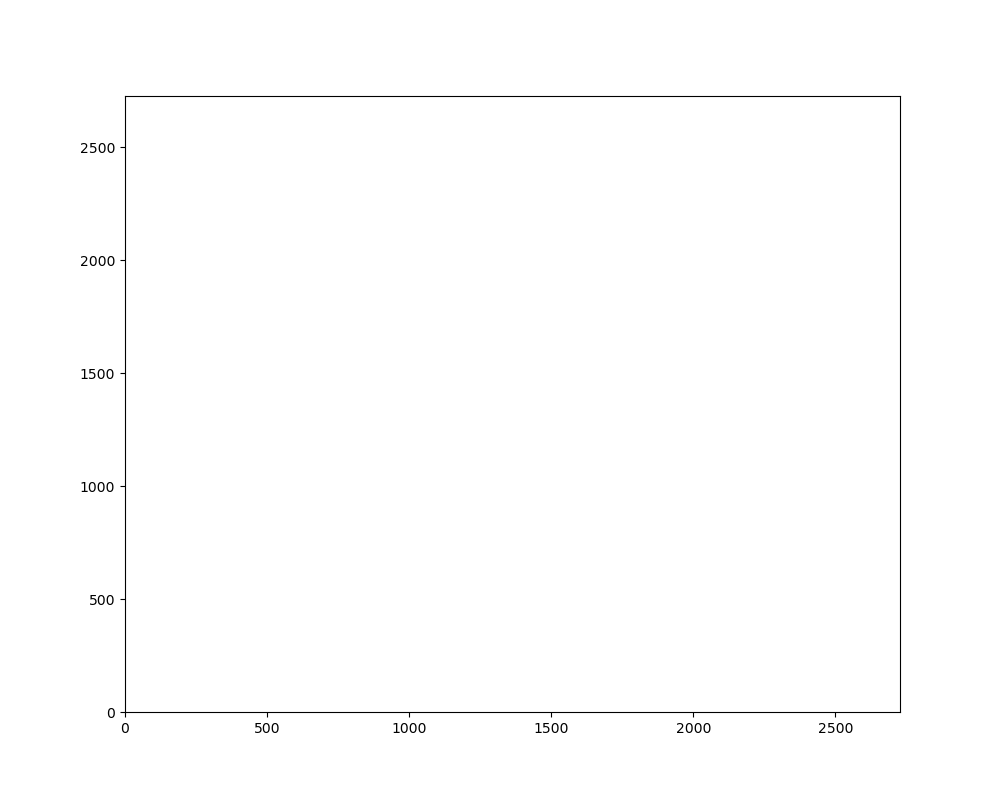

interactive(children=(ToggleButton(value=False, description='Auto Contrast', tooltip='Toggle auto contrast on/…

In [84]:
###### Plot mosaic ------------------------------------
from IPython.display import clear_output


folder = selected_dict['folder']
AUTOCONTRAST = False
USE_LOG_SCALE = True
default_range_log = [3.2, 3.5]
default_range_linear = [10**3.2, 10**3.5]
figsize = (10, 8)

# --- Store previous vmin/vmax and zoom/pan state ---
previous_vrange = {"log": default_range_log, "linear": default_range_linear}
zoom_state = None

# --- Create figure and axes once ---
fig, ax = plt.subplots(figsize=figsize)
ax.set_xlim(0,bigimage.shape[0])
ax.set_ylim(0,bigimage.shape[1])
plt.show()

# --- Store zoom/pan state before updates ---
def store_zoom_state(event):
    global zoom_state
    if event.name == 'draw_event':
        # Only store the state if the user has manually zoomed/panned
        current_limits = ax.get_xlim(), ax.get_ylim()
        if zoom_state is None:
            # First draw: do not store as user_zoomed
            zoom_state = {
                'xlim': current_limits[0],
                'ylim': current_limits[1],
                'data_lim': ax.dataLim.bounds
            }
        else:
            # Subsequent draws: mark as user_zoomed
            zoom_state = {
                'xlim': current_limits[0],
                'ylim': current_limits[1],
                'data_lim': ax.dataLim.bounds,
                'user_zoomed': True
            }


fig.canvas.mpl_connect('draw_event', store_zoom_state)

# --- Define the plotting function ---
def plot_mosaic(autocontrast, use_log, vrange):
    global zoom_state

    # Store current vmin/vmax for the current scale
    scale_key = "log" if use_log else "linear"
    previous_vrange[scale_key] = vrange

    ax.clear()
    data = np.log10(bigimage + 0.001) if use_log else bigimage
    vmin, vmax = vrange if not autocontrast else (None, None)

    im = ax.imshow(data, origin='lower', vmin=vmin, vmax=vmax)

    # --- Set full dimensions as default ---
    ax.set_xlim(0, data.shape[1])
    ax.set_ylim(0, data.shape[0])

    # --- Only restore zoom_state if it was set by user interaction (not the initial draw) ---
    print('zoom_state', zoom_state)
    if zoom_state and 'user_zoomed' in zoom_state:
        ax.set_xlim(zoom_state['xlim'])
        ax.set_ylim(zoom_state['ylim'])

    if selected_dict['fastaxis'] == 'yech':
        ax.set_xlabel(f"fastaxis {selected_dict['fastaxis']} // pixelY")
        ax.set_ylabel(f"slowaxis {selected_dict['slowaxis']} // pixelX")
    else:
        ax.set_xlabel(f"fastaxis {selected_dict['fastaxis']} // pixelX")
        ax.set_ylabel(f"slowaxis {selected_dict['slowaxis']} // pixelY")

    scale_str = "log" if use_log else "linear"
    title = f"{folder} roicenter X,Y = ({selected_dict['roicenter'][0]},{selected_dict['roicenter'][1]}) (scale: {scale_str})"
    fig.suptitle(title)
    ax.format_coord = format_coord

    fig.canvas.draw_idle()

    
# --- Create widgets ---
autocontrast_toggle = widgets.ToggleButton(
    value=AUTOCONTRAST,
    description='Auto Contrast',
    disabled=False,
    button_style='',
    tooltip='Toggle auto contrast on/off',
)

log_scale_toggle = widgets.ToggleButton(
    value=USE_LOG_SCALE,
    description='Log Scale',
    disabled=False,
    button_style='',
    tooltip='Toggle between log and linear scale',
)

vrange_slider = widgets.FloatRangeSlider(
    value=default_range_log,
    min=0.0,
    max=10.0,
    step=0.1,
    description='Contrast Range:',
    disabled=AUTOCONTRAST,
    continuous_update=True
)

# --- Convert vmin/vmax between scales ---
def convert_range(from_log, vrange):
    if from_log:
        return [10**v for v in vrange]  # Log → Linear
    else:
        return [np.log10(v) if v > 0 else 0 for v in vrange]  # Linear → Log (handle 0)

# --- Update slider when scale changes ---
def update_slider_range(change):
    use_log = change.new
    if use_log:
        # Switching to log: convert from linear to log
        new_vrange = convert_range(False, previous_vrange["linear"])
        vrange_slider.value = new_vrange
        vrange_slider.min, vrange_slider.max, vrange_slider.step = 0.0, 10.0, 0.1
    else:
        # Switching to linear: convert from log to linear
        new_vrange = convert_range(True, previous_vrange["log"])
        vrange_slider.value = new_vrange
        vrange_slider.min, vrange_slider.max, vrange_slider.step = 0.0, 10000.0, 100.0

log_scale_toggle.observe(update_slider_range, names='value')

# --- Restore vmin/vmax when AUTOCONTRAST is toggled off ---
def update_slider_disabled(change):
    vrange_slider.disabled = change.new
    if not change.new:  # AUTOCONTRAST turned off
        scale_key = "log" if log_scale_toggle.value else "linear"
        vrange_slider.value = previous_vrange[scale_key]

autocontrast_toggle.observe(update_slider_disabled, names='value')

# --- Initialize with widgets.interactive ---
widgets.interactive(
    plot_mosaic,
    autocontrast=autocontrast_toggle,
    use_log=log_scale_toggle,
    vrange=vrange_slider
)